In [138]:
import torch 
import torchvision
import torch.nn as nn 
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd 
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt 
import numpy as np 
import os 
import shutil
from pathlib import Path 

In [139]:
## Device Configuration ## 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [140]:
## Preprocessing ##

In [141]:
os.getcwd()

'c:\\Users\\isaac\\Documents\\GitHub\\MStar-ImageClassification'

In [142]:
## Split the dataset ##

In [143]:
root_dir=r"C:\Users\isaac\Documents\Personal_Projects\AI\image_class\Scripts\MSTAR-PublicMixedTargets-CD1\MSTAR_PUBLIC_MIXED_TARGETS_CD1\15_DEG\COL2\SCENE1"
root = os.listdir(root_dir)

In [95]:
# Extract Images and Labels

labels = []
images = []

for cls in root:
    cls_dir = Path(os.path.join(root_dir, cls))
    for img_path in cls_dir.rglob("*.JPG"):
        img = Image.open(img_path)
        img = img.resize((128,128))
        images.append(np.array(img))
        labels.append(cls)

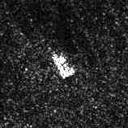

In [96]:
img # Test image retrieval 

In [97]:
X = np.array(images)
y = np.array(labels)

In [98]:
X = X / 255 # Normalize
X = X[...,np.newaxis]

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

X = torch.tensor(X, dtype=torch.float32)  # (1917, 128, 128, 1)
X = X.permute(0, 3, 1, 2)                 # (1917, 1, 128, 128) PyTorch expects (N, C, H, W)
y = torch.tensor(y, dtype=torch.long)

In [99]:
# Train Test Split 

batch_size = 128

x_train, x_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

train_dataset = TensorDataset(x_train, y_train)
test_dataset = TensorDataset(x_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [100]:
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6], dtype=int64)

In [102]:
class MStarCNN(nn.Module):
    def __init__(self): 
        super().__init__() 
        self.model = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32,
                            kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout(0.2),
            nn.Conv2d(in_channels=32, out_channels=64,
                            kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout(0.2),
            nn.Flatten(),
            nn.Linear(64 * 32 * 32, 128),
            nn.ReLU(),
            nn.Linear(128, 7)
        )
    
    def forward(self,x): 
        return self.model(x)

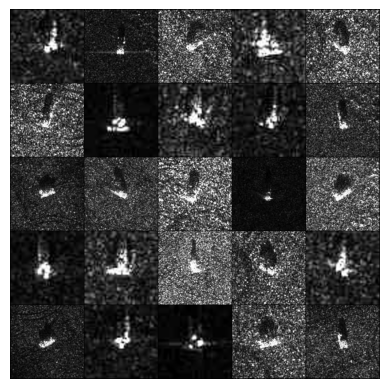

In [103]:
dataiter = iter(train_loader)
images, labels = next(dataiter)
images

plt.imshow(np.transpose(torchvision.utils.make_grid(
    images[:25], normalize=True, padding=1, nrow=5).numpy(), (1, 2, 0)))
plt.axis('off')
plt.show()

In [104]:
model = MStarCNN().to(device)

In [105]:
# Hyperparamters

num_epochs = 10
learning_rate = 0.0001
weight_decay = 0.001
torch.manual_seed(283) # Set Seed for reproducibility 

weights = compute_class_weight('balanced', classes=np.array([0,1,2,3,4,5,6]), y=y_train.numpy())
weights = torch.tensor(weights, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.Adam(
    model.parameters(), lr=learning_rate, weight_decay=weight_decay)

In [37]:
# Training plus Validation

train_loss_list = []
all_preds  = []
all_labels = []

for epoch in range(num_epochs): 
    train_loss= 0
    model.train() 

    for images, labels in train_loader: 
        images = images.to(device)
        labels = labels.to(device)

        output = model(images)

        loss = criterion(output, labels)
        optimizer.zero_grad() 
        loss.backward()
        optimizer.step()
        train_loss+= loss.item()
    
    train_loss_list.append(train_loss/len(train_loader))
    print(f"Training Loss = {train_loss_list[-1]}")

    # Validation 

    model.eval() 

    correct = 0 
    total = 0 

    with torch.no_grad():
        for images, labels in test_loader: 
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs,1)
            correct += (predicted==labels).sum().item() 
            total += labels.size(0)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    val_acc = correct / total
    print(f"epochs:{epoch+1} | Val_acc:{val_acc}") 

Training Loss = 0.04439860008036097
epochs:1 | Val_acc:0.9869791666666666
Training Loss = 0.03595134848728776
epochs:2 | Val_acc:0.9869791666666666
Training Loss = 0.03210073717248937
epochs:3 | Val_acc:0.9869791666666666
Training Loss = 0.028424625905851524
epochs:4 | Val_acc:0.9869791666666666
Training Loss = 0.027985441653678816
epochs:5 | Val_acc:0.9869791666666666
Training Loss = 0.027536484180018306
epochs:6 | Val_acc:0.9869791666666666
Training Loss = 0.026945899007841945
epochs:7 | Val_acc:0.9869791666666666
Training Loss = 0.02445114287547767
epochs:8 | Val_acc:0.9869791666666666
Training Loss = 0.026576868646467727
epochs:9 | Val_acc:0.9869791666666666
Training Loss = 0.024593415126825374
epochs:10 | Val_acc:0.9869791666666666


In [24]:
# Model Accuracy after 10 epochs: 95-99%

In [106]:
cm = confusion_matrix(all_labels, all_preds) # Classification 

In [107]:
import seaborn as sns

Text(50.722222222222214, 0.5, 'Predicted Labels')

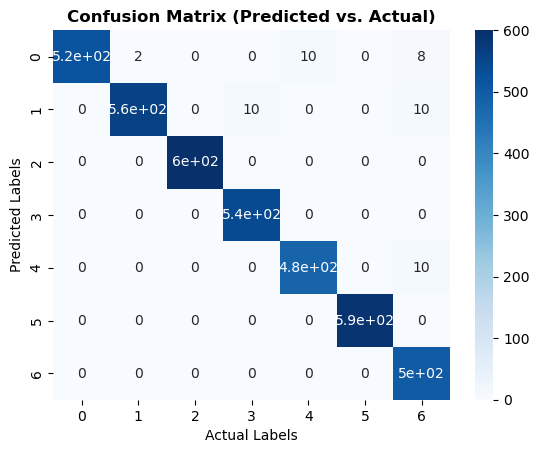

In [108]:
sns.heatmap(cm, annot=True, cmap="Blues")
plt.title("Confusion Matrix (Predicted vs. Actual)", fontweight="bold")
plt.xlabel("Actual Labels")
plt.ylabel("Predicted Labels")

In [ ]:
""" 
The plot is fairly good until label 6. We see the most misclassifications here. 
The possible reason is due to the similiarity of scattering patterns. 
Potential Solutions: 

- Class weights - added changes
- Epoch changes - added changes
- Learning rate - added changes
- Data Augmentation (Image Rotation)

"""

' \nThe plot is fairly good until label 6. We see the most misclassifications here. \nThe possible reason is due to the similiarity of scattering patterns. \nPotential Solutions: \n\n- Class weights\n- Epoch changes\n- Data Augmentation (Image Rotation)\n\n'

In [80]:
# Do the changes work? - The classification is much better with the changes. 

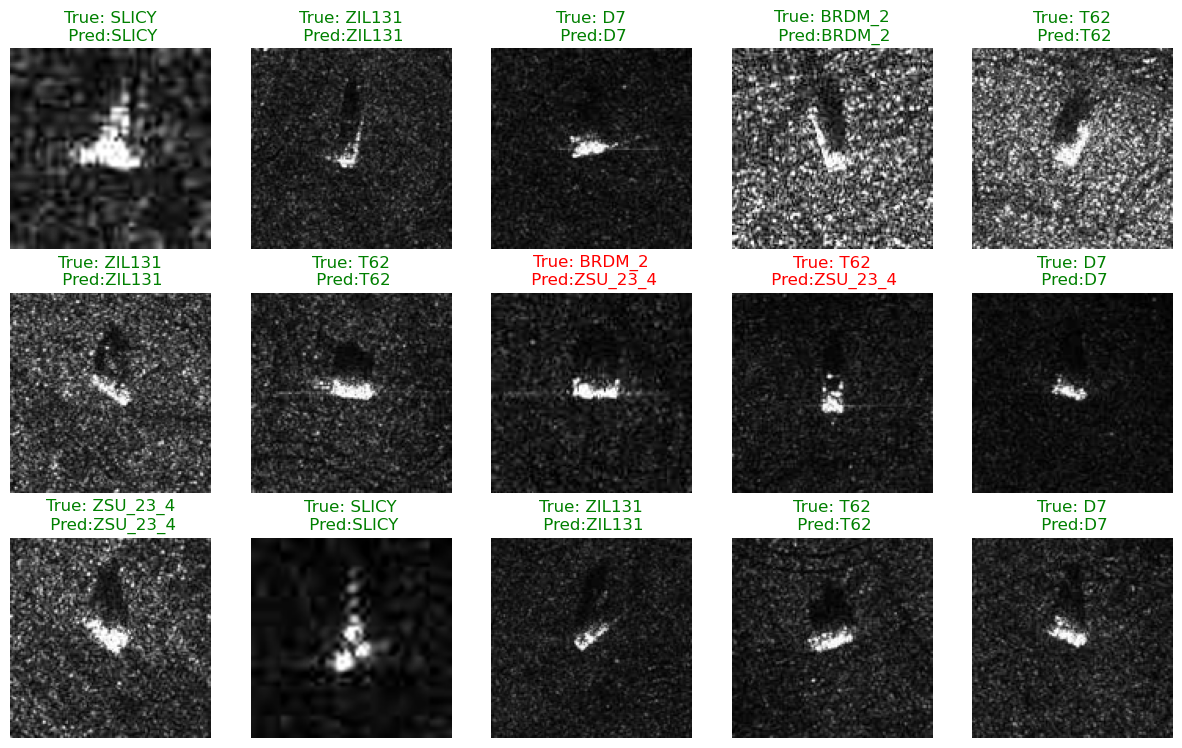

In [109]:
# Visual of Predictions 

fig, axes = plt.subplots(3,5, figsize=(15,9))

for i, ax in enumerate(axes.flat): 
    img = x_test[i].squeeze().numpy()
    true = le.classes_[all_labels[i]]
    pred = le.classes_[all_preds[i]]
    color = "green" if true == pred else "red"
    ax.imshow(img,cmap="gray")
    ax.set_title(f"True: {true}\n Pred:{pred}", color=color)
    ax.axis("off")

plt.show()

## YOLOv8 (Vehicle Detection using OBB)

In [43]:
from ultralytics import YOLO

In [202]:
# Load the model weights 

Yol_model = YOLO("yolov8n-obb.pt")

In [203]:
# Take the training/val data and create folders that can process with YOLO

In [224]:
# Possible issue: 

"""
The SAR images are grayscale which causes issues when dealing with YOLO because it expects 
the images to have a conversion to RGB. This requires that the images be converted before storing. 

"""

classes = sorted(set(labels))
class_to_idx = {cls: i for i, cls in enumerate(classes)}


source_dir = r"C:\Users\isaac\Documents\GitHub\MStar-ImageClassification\mstar_yolo"
root_dir = r"C:\Users\isaac\Documents\GitHub\MStar-ImageClassification\MSTAR-PublicMixedTargets-CD1\MSTAR_PUBLIC_MIXED_TARGETS_CD1\15_DEG\COL2\SCENE1"
root = os.listdir(root_dir)
def traintestfolder(images, labels, split, source_dir):
    img_dir = os.path.join(source_dir, split, "images")  # train/images
    lab_dir = os.path.join(source_dir, split, "labels")  # train/labels
    os.makedirs(img_dir, exist_ok=True)
    os.makedirs(lab_dir, exist_ok=True)

    for img_path, cls in zip(images, labels):
        img = Image.open(img_path).convert("RGB")
        img_name = os.path.basename(img_path)
        img.save(os.path.join(img_dir, img_name))

        stem = Path(img_path).stem
        with open(os.path.join(lab_dir, f"{stem}.txt"), 'w') as f:
            f.write(f"{class_to_idx[cls]} 0.5 0.5 1.0 1.0\n")


In [225]:
labels = []
images = []
imgpath = []

for cls in root:
    cls_dir = Path(os.path.join(root_dir, cls))
    for img_path in cls_dir.rglob("*.JPG"):
        img = Image.open(img_path)
        img = img.resize((128,128))
        images.append(img)
        imgpath.append(Path(img_path))
        labels.append(cls)


train_imgs, test_imgs, train_labs, test_labs = train_test_split(
    imgpath, labels, test_size=0.2, random_state=42, stratify=labels
)

In [226]:
# No need to rreun, establishes files once. 
traintestfolder(train_imgs, train_labs, split="train", source_dir=source_dir) # Store the training images and labels 
traintestfolder(test_imgs, test_labs, split="test", source_dir=source_dir)    # Store the testing images and labels 

In [236]:
results = Yol_model.train(data=r'C:\Users\isaac\Documents\GitHub\MStar-ImageClassification\mstar_yolo\Mstar.yaml',epochs = 20, imgsz=128, patience=5)

New https://pypi.org/project/ultralytics/8.4.64 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.63  Python-3.12.7 torch-2.7.1+cpu CPU (Intel Core Ultra 7 155U)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\isaac\Documents\GitHub\MStar-ImageClassification\mstar_yolo\Mstar.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=128, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-obb.pt, mo

RuntimeError: Dataset 'C://Users/isaac/Documents/GitHub/MStar-ImageClassification/mstar_yolo/Mstar.yaml' error  Dataset 'C://Users/isaac/Documents/GitHub/MStar-ImageClassification/mstar_yolo/Mstar.yaml' images not found, missing path 'C:\Users\isaac\Documents\GitHub\MStar-ImageClassification\mstar_yolo\mstar_yolo\test'
Note dataset download directory is 'C:\Users\isaac\Documents\Personal_Projects\AI\VideoRec\Scripts\datasets'. You can update this in 'C:\Users\isaac\AppData\Roaming\Ultralytics\settings.json'

In [221]:
metrics = Yol_model.val(data = r"C:\Users\isaac\Documents\GitHub\MStar-ImageClassification\mstar_yolo\Mstar.yaml", plots=True)

Ultralytics 8.4.63  Python-3.12.7 torch-2.7.1+cpu CPU (Intel Core Ultra 7 155U)
val: Fast image access  (ping: 0.10.0 ms, read: 6.12.7 MB/s, size: 8.5 KB)
val: Scanning C:\Users\isaac\Documents\GitHub\MStar-ImageClassification\mstar_yolo\test\labels.cache... 221 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 221/221  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 0% ──────────── 0/14  4.0s


IndexError: The shape of the mask [16] at index 0 does not match the shape of the indexed tensor [0, 5] at index 0

In [217]:
# Validation Metrics

metrics.box.map  
metrics.box.map50  
metrics.box.map75  
metrics.box.maps  
metrics.box.image_metrics

{'HB14939.JPG': {'precision': 1.0,
  'recall': 1.0,
  'f1': 1.0,
  'tp': 0,
  'fp': 0,
  'fn': 0},
 'HB15078.JPG': {'precision': 1.0,
  'recall': 1.0,
  'f1': 1.0,
  'tp': 0,
  'fp': 0,
  'fn': 0},
 'HB15082.JPG': {'precision': 1.0,
  'recall': 1.0,
  'f1': 1.0,
  'tp': 0,
  'fp': 0,
  'fn': 0},
 'HB15111.JPG': {'precision': 0.0,
  'recall': 0.0,
  'f1': 0.0,
  'tp': 0,
  'fp': 1,
  'fn': 0},
 'HB15117.JPG': {'precision': 1.0,
  'recall': 1.0,
  'f1': 1.0,
  'tp': 0,
  'fp': 0,
  'fn': 0},
 'HB15130.JPG': {'precision': 1.0,
  'recall': 1.0,
  'f1': 1.0,
  'tp': 0,
  'fp': 0,
  'fn': 0},
 'HB15143.JPG': {'precision': 1.0,
  'recall': 1.0,
  'f1': 1.0,
  'tp': 0,
  'fp': 0,
  'fn': 0},
 'HB15151.JPG': {'precision': 1.0,
  'recall': 1.0,
  'f1': 1.0,
  'tp': 0,
  'fp': 0,
  'fn': 0},
 'HB15182.JPG': {'precision': 0.0,
  'recall': 0.0,
  'f1': 0.0,
  'tp': 0,
  'fp': 6,
  'fn': 0},
 'HB15193.JPG': {'precision': 1.0,
  'recall': 1.0,
  'f1': 1.0,
  'tp': 0,
  'fp': 0,
  'fn': 0},
 'HB15194.

In [220]:
Yol_model.export(format="onnx")

Ultralytics 8.4.63  Python-3.12.7 torch-2.7.1+cpu CPU (Intel Core Ultra 7 155U)

PyTorch: starting from 'yolov8n-obb.pt' with input shape (1, 3, 1024, 1024) BCHW and output shape(s) (1, 20, 21504) (6.3 MB)

ONNX: starting export with onnx 1.21.0 opset 19...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success  1.0s, saved as 'yolov8n-obb.onnx' (12.1 MB)

Export complete (1.5s)
Results saved to C:\Users\isaac\Documents\GitHub\MStar-ImageClassification\yolov8n-obb.onnx
Predict:         yolo predict task=obb model=yolov8n-obb.onnx imgsz=1024 
Validate:        yolo val task=obb model=yolov8n-obb.onnx imgsz=1024 data=runs/DOTAv1.0-ms.yaml  
Visualize:       https://netron.app


'yolov8n-obb.onnx'

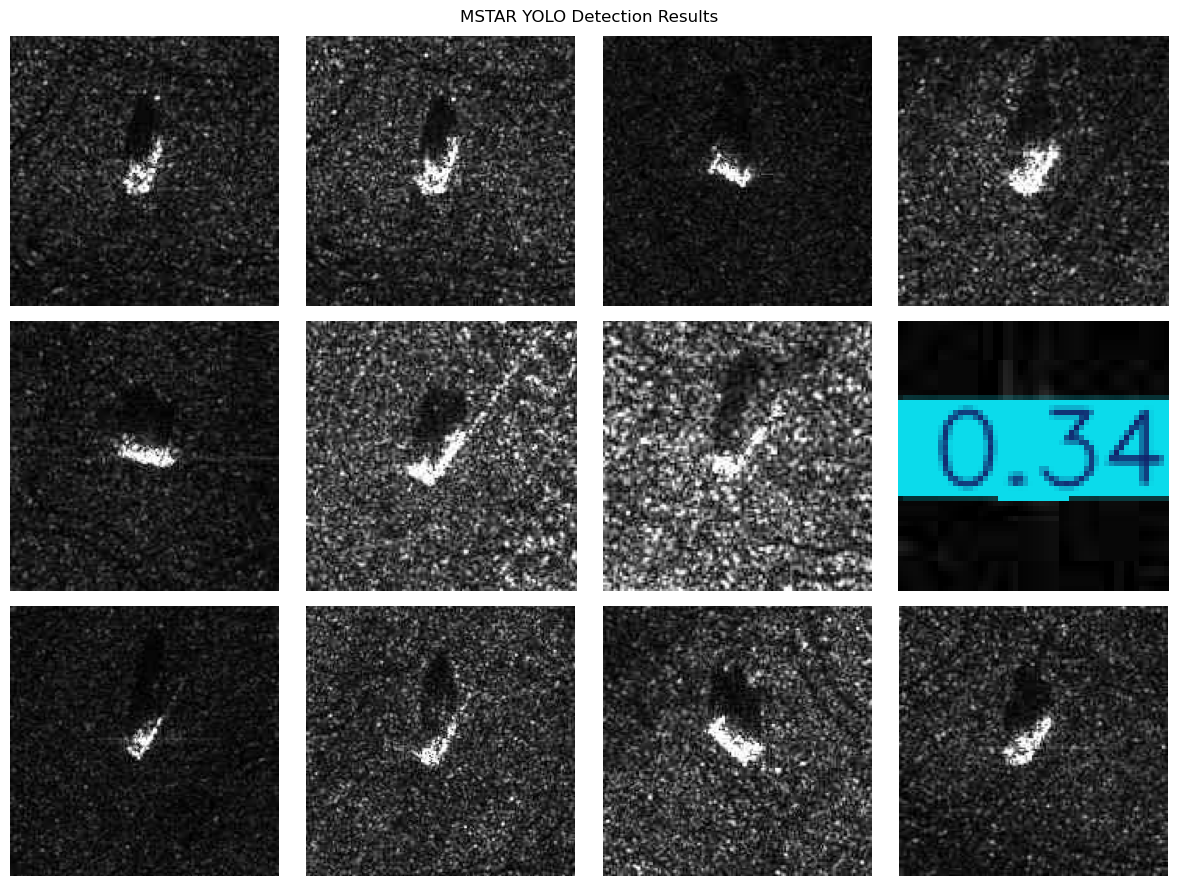

In [223]:
fig, axes = plt.subplots(3, 4, figsize=(12, 9))
for ax, img_path in zip(axes.flat, test_imgs[:12]):
    result = Yol_model.predict(img_path, verbose=False, conf=0.25)[0]
    annotated = result.plot()  # returns BGR numpy array with boxes drawn
    ax.imshow(annotated[:, :, ::-1])  # BGR -> RGB
    ax.axis("off")

plt.suptitle("MSTAR YOLO Detection Results")
plt.tight_layout()
plt.show()